# Module 3 — Live Signals Dashboard
**Zaeem Hasan | Quant Portfolio Study**

Pulls fresh data on every run. No stale signals.

**Five signal types:**
- **RSI** — momentum (overbought >70, oversold <30)
- **MA Crossover** — 50/200-day trend direction (golden/death cross)
- **Bollinger Bands** — price position within volatility envelope
- **Z-Score** — standard deviations from 60-day mean
- **Volume Anomaly** — today's volume vs 20-day average

**Output:** Signal table first (scannable), then charts only for tickers with active signals.


In [10]:
# ── 0. Dependencies ──────────────────────────────────────────────────────────
!pip install yfinance pandas numpy matplotlib seaborn --quiet

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
# ── 1. Imports ───────────────────────────────────────────────────────────────
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mtick
import seaborn as sns
from datetime import date, timedelta
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f9f9f9',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'axes.spines.top':  False,
    'axes.spines.right':False
})

DRIVE_PATH = '/content/drive/MyDrive/quant-project/'
TICKERS    = ['LITE','AMD','COHR','GOOG','MRVL','GLD','VRT','EQIX','AVGO','SNDR','ANET']
TODAY      = date.today().strftime('%Y-%m-%d')
# Pull 1 year for MA200 to be meaningful
LOOKBACK   = (date.today() - timedelta(days=365)).strftime('%Y-%m-%d')

print(f'Run date: {TODAY}')
print(f'Lookback: {LOOKBACK}')

Run date: 2026-04-08
Lookback: 2025-04-08


In [12]:
# ── 2. Pull fresh data ───────────────────────────────────────────────────────
# Module 3 always re-pulls — signals need to be live, not from saved CSVs.
print('Pulling fresh price + volume data...')
raw    = yf.download(TICKERS, start=LOOKBACK, end=TODAY,
                     auto_adjust=True, progress=False)
prices = raw['Close'].copy()
volume = raw['Volume'].copy()
prices.index = pd.to_datetime(prices.index)
volume.index = pd.to_datetime(volume.index)

print(f'Tickers: {list(prices.columns)}')
print(f'Days of data: {len(prices)}')
print(f'Latest date:  {prices.index[-1].date()}')

Pulling fresh price + volume data...
Tickers: ['AMD', 'ANET', 'AVGO', 'COHR', 'EQIX', 'GLD', 'GOOG', 'LITE', 'MRVL', 'SNDR', 'VRT']
Days of data: 250
Latest date:  2026-04-07


In [13]:
# ── 3. Signal calculations ───────────────────────────────────────────────────

def calc_rsi(series, period=14):
    """Relative Strength Index — momentum oscillator 0-100."""
    delta = series.diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=period-1, adjust=False).mean()
    avg_loss = loss.ewm(com=period-1, adjust=False).mean()
    rs  = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

def calc_bollinger(series, window=20, n_std=2):
    """Bollinger Bands — volatility envelope around rolling mean."""
    mid   = series.rolling(window).mean()
    std   = series.rolling(window).std()
    upper = mid + n_std * std
    lower = mid - n_std * std
    # %B: where price sits within the band (0=lower, 1=upper)
    pct_b = (series - lower) / (upper - lower)
    return mid, upper, lower, pct_b

def calc_zscore(series, window=60):
    """Z-score: how many std devs from rolling mean."""
    rolling_mean = series.rolling(window).mean()
    rolling_std  = series.rolling(window).std()
    return (series - rolling_mean) / rolling_std

def volume_ratio(vol_series, window=20):
    """Today's volume vs 20-day average."""
    return vol_series / vol_series.rolling(window).mean()

print('Signal functions defined.')

Signal functions defined.


In [14]:
# ── 4. Compute all signals, build summary table ──────────────────────────────
rows = []

for t in TICKERS:
    if t not in prices.columns:
        continue

    p   = prices[t].dropna()
    v   = volume[t].dropna() if t in volume.columns else None

    # RSI
    rsi      = calc_rsi(p).iloc[-1]
    rsi_flag = 'OVERBOUGHT' if rsi > 70 else ('OVERSOLD' if rsi < 30 else 'NEUTRAL')

    # Moving averages
    ma50  = p.rolling(50).mean().iloc[-1]
    ma200 = p.rolling(200).mean().iloc[-1]
    price_now = p.iloc[-1]
    if ma50 > ma200:
        ma_signal = 'GOLDEN CROSS'   # bullish
    else:
        ma_signal = 'DEATH CROSS'    # bearish
    price_vs_ma50  = (price_now / ma50  - 1) * 100
    price_vs_ma200 = (price_now / ma200 - 1) * 100

    # Bollinger Bands
    mid, upper, lower, pct_b = calc_bollinger(p)
    pct_b_now = pct_b.iloc[-1]
    if pct_b_now > 1.0:
        bb_flag = 'ABOVE UPPER'
    elif pct_b_now > 0.8:
        bb_flag = 'NEAR UPPER'
    elif pct_b_now < 0.0:
        bb_flag = 'BELOW LOWER'
    elif pct_b_now < 0.2:
        bb_flag = 'NEAR LOWER'
    else:
        bb_flag = 'MID BAND'

    # Z-score
    z = calc_zscore(p).iloc[-1]
    z_flag = 'EXTENDED' if z > 2 else ('CHEAP' if z < -2 else 'NORMAL')

    # Volume
    if v is not None and len(v) > 20:
        vol_r = volume_ratio(v).iloc[-1]
        vol_flag = 'HIGH VOL' if vol_r > 1.5 else ('LOW VOL' if vol_r < 0.5 else 'NORMAL')
    else:
        vol_r    = np.nan
        vol_flag = 'N/A'

    rows.append({
        'Ticker':       t,
        'Price':        round(price_now, 2),
        'RSI':          round(rsi, 1),
        'RSI Signal':   rsi_flag,
        'MA Signal':    ma_signal,
        'vs MA50 (%)':  round(price_vs_ma50, 1),
        'vs MA200 (%)': round(price_vs_ma200, 1),
        'BB %B':        round(pct_b_now, 2),
        'BB Signal':    bb_flag,
        'Z-Score':      round(z, 2),
        'Z Signal':     z_flag,
        'Vol Ratio':    round(vol_r, 2) if not np.isnan(vol_r) else 'N/A',
        'Vol Signal':   vol_flag
    })

signals_df = pd.DataFrame(rows)
print(signals_df[['Ticker','Price','RSI','RSI Signal','MA Signal',
                   'BB Signal','Z-Score','Z Signal','Vol Signal']].to_string(index=False))

Ticker   Price  RSI RSI Signal    MA Signal  BB Signal  Z-Score Z Signal Vol Signal
  LITE  815.75 59.9    NEUTRAL GOLDEN CROSS NEAR UPPER     1.52   NORMAL     NORMAL
   AMD  221.53 59.7    NEUTRAL GOLDEN CROSS NEAR UPPER     0.42   NORMAL     NORMAL
  COHR  255.10 52.3    NEUTRAL GOLDEN CROSS   MID BAND     0.77   NORMAL    LOW VOL
  GOOG  303.93 54.8    NEUTRAL GOLDEN CROSS   MID BAND    -0.50   NORMAL     NORMAL
  MRVL  109.38 69.0    NEUTRAL GOLDEN CROSS NEAR UPPER     2.79 EXTENDED     NORMAL
   GLD  431.81 47.3    NEUTRAL GOLDEN CROSS   MID BAND    -0.74   NORMAL    LOW VOL
   VRT  262.30 54.6    NEUTRAL GOLDEN CROSS   MID BAND     0.92   NORMAL    LOW VOL
  EQIX 1007.29 68.4    NEUTRAL GOLDEN CROSS NEAR UPPER     1.30   NORMAL     NORMAL
  AVGO  333.97 57.9    NEUTRAL  DEATH CROSS NEAR UPPER     0.57   NORMAL     NORMAL
  SNDR   27.44 61.8    NEUTRAL GOLDEN CROSS NEAR UPPER    -0.04   NORMAL     NORMAL
  ANET  133.64 53.3    NEUTRAL GOLDEN CROSS   MID BAND     0.01   NORMAL    

In [15]:
# ── 5. Composite signal score ─────────────────────────────────────────────────
# Aggregate all signals into one score: +1 = bullish, -1 = bearish, 0 = neutral
# Useful for ranking tickers by overall signal strength.

def score_row(row):
    score = 0
    # RSI
    if row['RSI Signal'] == 'OVERSOLD':    score += 1
    if row['RSI Signal'] == 'OVERBOUGHT':  score -= 1
    # MA
    if row['MA Signal'] == 'GOLDEN CROSS': score += 1
    if row['MA Signal'] == 'DEATH CROSS':  score -= 1
    # Bollinger
    if row['BB Signal'] in ('NEAR LOWER','BELOW LOWER'): score += 1
    if row['BB Signal'] in ('NEAR UPPER','ABOVE UPPER'): score -= 1
    # Z-score
    if row['Z Signal'] == 'CHEAP':    score += 1
    if row['Z Signal'] == 'EXTENDED': score -= 1
    return score

signals_df['Composite Score'] = signals_df.apply(score_row, axis=1)
signals_df = signals_df.sort_values('Composite Score', ascending=False)

print('── Composite Signal Ranking ──────────────────────────')
print('  +4 = strong bullish signals across all indicators')
print('  -4 = strong bearish signals across all indicators')
print()
print(signals_df[['Ticker','Price','RSI','Composite Score',
                   'RSI Signal','MA Signal','BB Signal','Z Signal']].to_string(index=False))

── Composite Signal Ranking ──────────────────────────
  +4 = strong bullish signals across all indicators
  -4 = strong bearish signals across all indicators

Ticker   Price  RSI  Composite Score RSI Signal    MA Signal  BB Signal Z Signal
  COHR  255.10 52.3                1    NEUTRAL GOLDEN CROSS   MID BAND   NORMAL
   GLD  431.81 47.3                1    NEUTRAL GOLDEN CROSS   MID BAND   NORMAL
  GOOG  303.93 54.8                1    NEUTRAL GOLDEN CROSS   MID BAND   NORMAL
   VRT  262.30 54.6                1    NEUTRAL GOLDEN CROSS   MID BAND   NORMAL
  ANET  133.64 53.3                1    NEUTRAL GOLDEN CROSS   MID BAND   NORMAL
   AMD  221.53 59.7                0    NEUTRAL GOLDEN CROSS NEAR UPPER   NORMAL
  LITE  815.75 59.9                0    NEUTRAL GOLDEN CROSS NEAR UPPER   NORMAL
  SNDR   27.44 61.8                0    NEUTRAL GOLDEN CROSS NEAR UPPER   NORMAL
  EQIX 1007.29 68.4                0    NEUTRAL GOLDEN CROSS NEAR UPPER   NORMAL
  MRVL  109.38 69.0           

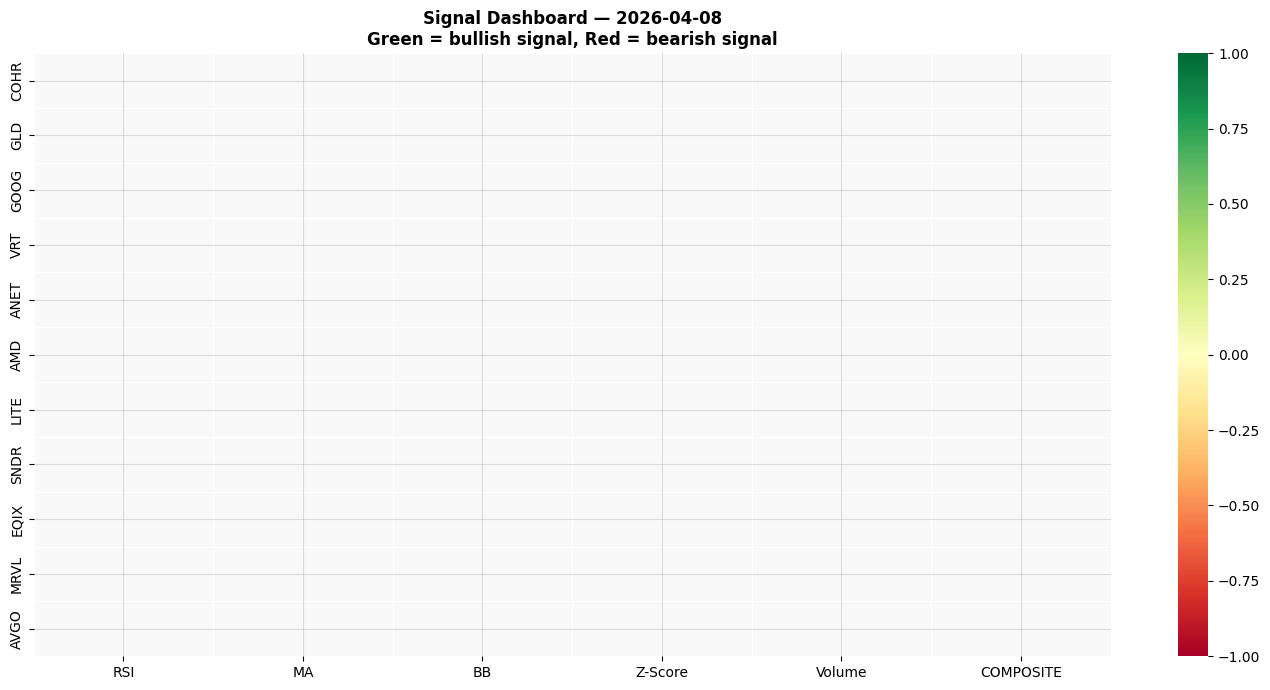

Signal dashboard saved.


In [16]:
# ── 6. Dashboard: signal heatmap ─────────────────────────────────────────────

def encode_rsi(s):   return {'OVERSOLD': 1, 'NEUTRAL': 0, 'OVERBOUGHT': -1}[s]
def encode_ma(s):    return {'GOLDEN CROSS': 1, 'DEATH CROSS': -1}[s]
def encode_bb(s):    return {'BELOW LOWER': 1, 'NEAR LOWER': 0.5, 'MID BAND': 0,
                              'NEAR UPPER': -0.5, 'ABOVE UPPER': -1}[s]
def encode_z(s):     return {'CHEAP': 1, 'NORMAL': 0, 'EXTENDED': -1}[s]
def encode_vol(s):   return {'HIGH VOL': 1, 'NORMAL': 0, 'LOW VOL': -0.5, 'N/A': 0}[s]

# Reset index first to guarantee alignment
df = signals_df.reset_index(drop=True)

heatmap_data = pd.DataFrame({
    'RSI':       df['RSI Signal'].map(encode_rsi),
    'MA':        df['MA Signal'].map(encode_ma),
    'BB':        df['BB Signal'].map(encode_bb),
    'Z-Score':   df['Z Signal'].map(encode_z),
    'Volume':    df['Vol Signal'].map(encode_vol),
    'COMPOSITE': df['Composite Score'] / 4
}, index=df['Ticker'].values)   # use .values to avoid index mismatch

annot_data = pd.DataFrame({
    'RSI':       df['RSI Signal'].values,
    'MA':        df['MA Signal'].values,
    'BB':        df['BB Signal'].values,
    'Z-Score':   df['Z Signal'].values,
    'Volume':    df['Vol Signal'].values,
    'COMPOSITE': df['Composite Score'].astype(str).values
}, index=df['Ticker'].values)   # same .values here

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    heatmap_data,
    annot=annot_data.values,    # pass numpy array, not DataFrame — bypasses index alignment entirely
    fmt='',
    cmap='RdYlGn',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 8, 'weight': 'bold'},
    yticklabels=df['Ticker'].values,
    ax=ax
)
ax.set_title(f'Signal Dashboard — {TODAY}\nGreen = bullish signal, Red = bearish signal',
             fontsize=12, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'module3_signal_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Signal dashboard saved.')

Active signal tickers: ['COHR', 'GLD', 'GOOG', 'VRT', 'ANET', 'MRVL', 'AVGO']


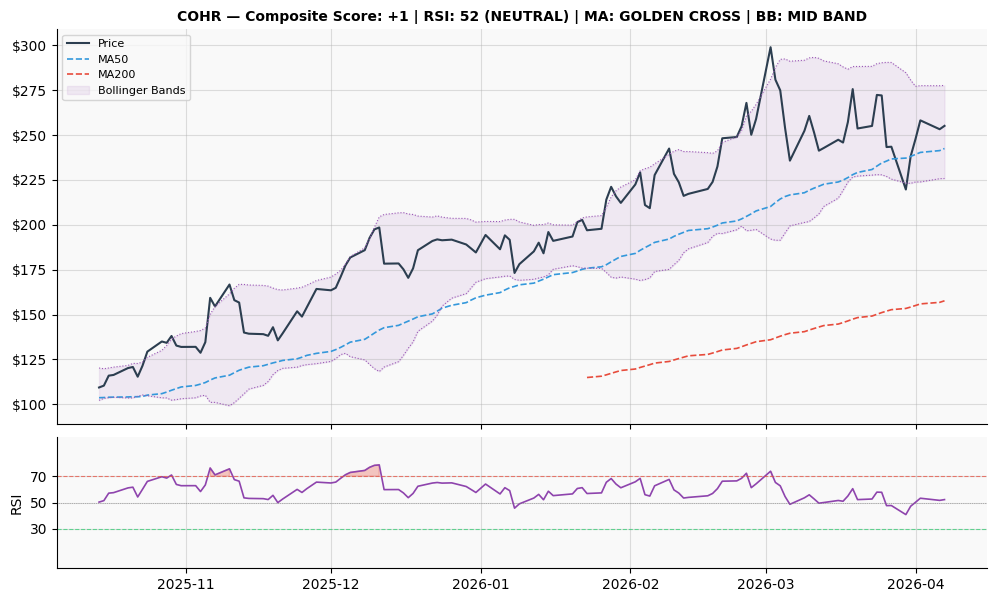

  COHR chart saved.


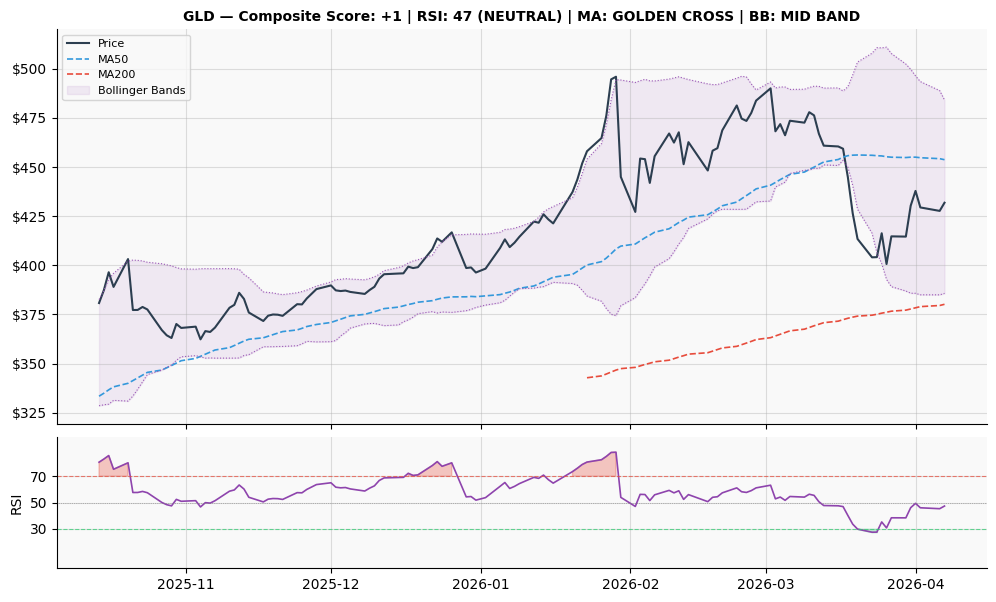

  GLD chart saved.


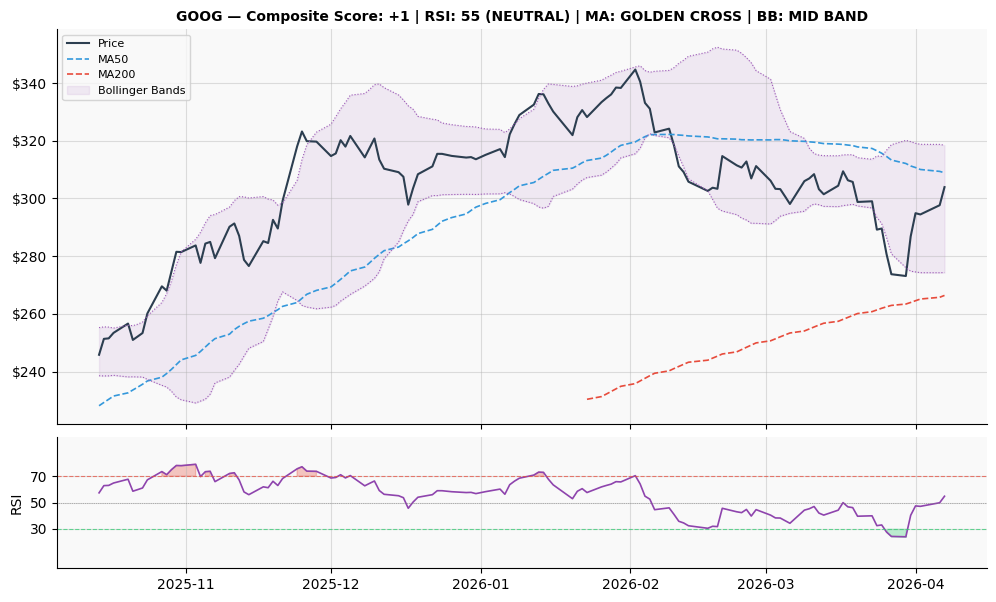

  GOOG chart saved.


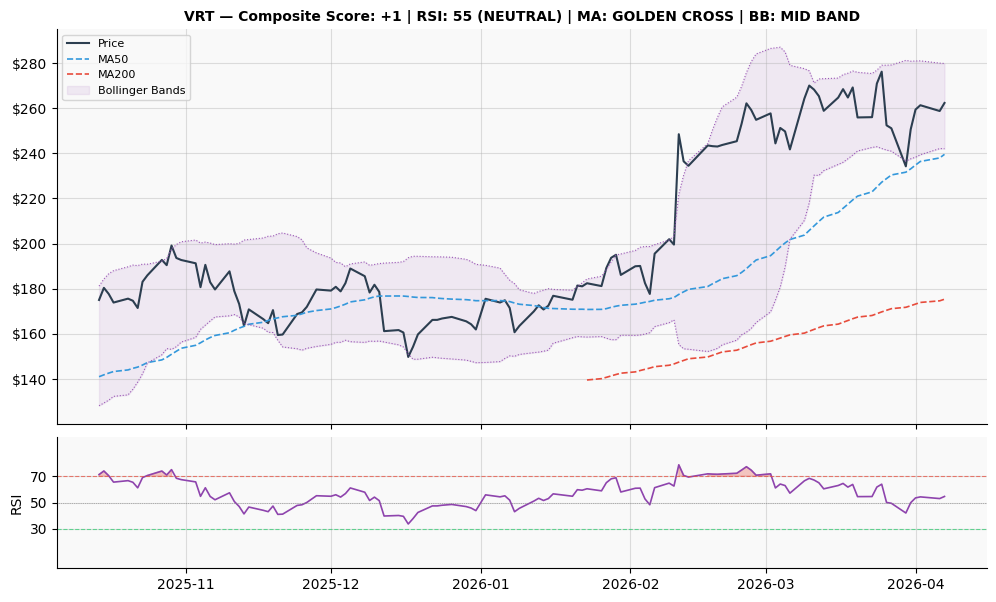

  VRT chart saved.


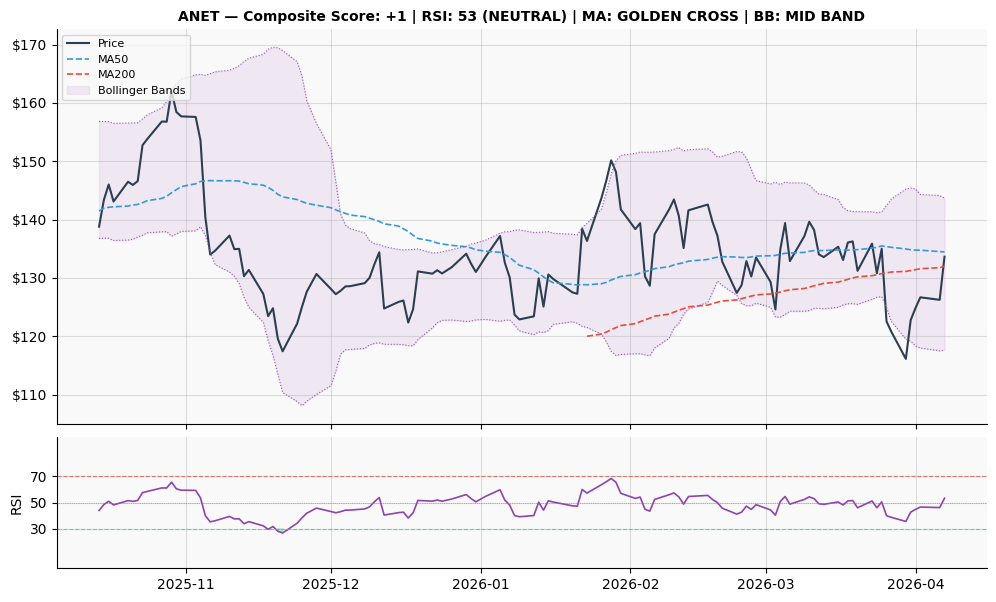

  ANET chart saved.


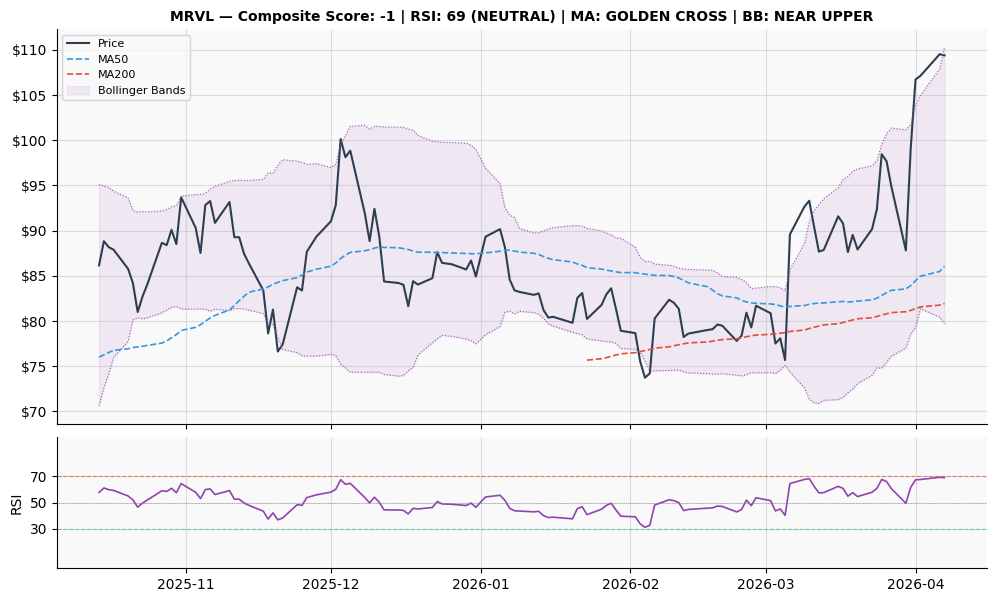

  MRVL chart saved.


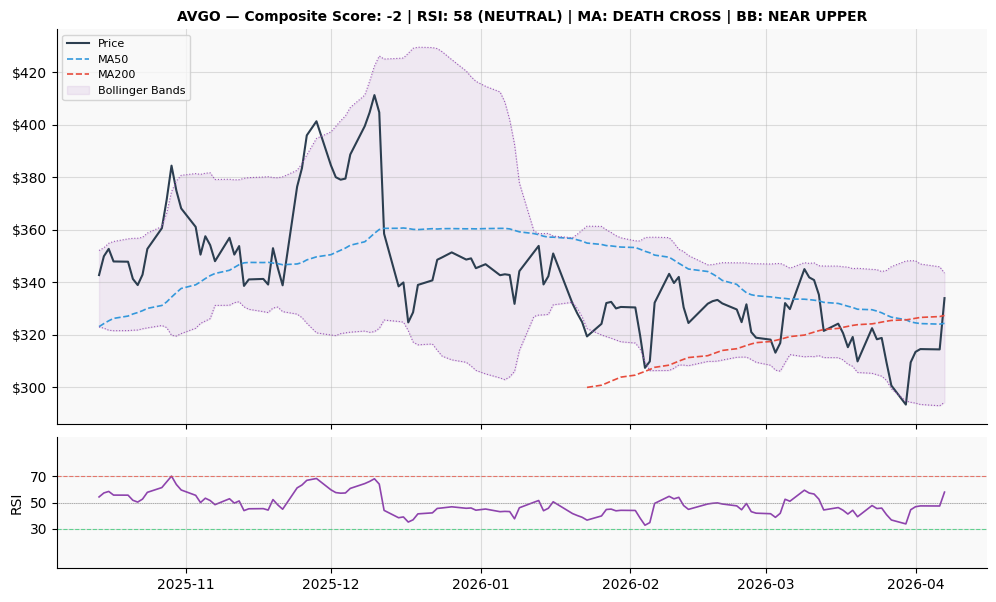

  AVGO chart saved.


In [17]:
# ── 7. Charts for tickers with active signals ─────────────────────────────────
# Only plot tickers where composite score != 0 — skip neutral ones.
# Each chart: price + MA50/200 + Bollinger Bands + RSI subplot.

active = signals_df[signals_df['Composite Score'] != 0]['Ticker'].tolist()
print(f'Active signal tickers: {active}')

for t in active:
    p = prices[t].dropna()
    # Need enough data for MA200
    if len(p) < 60:
        continue

    ma50_s  = p.rolling(50).mean()
    ma200_s = p.rolling(200).mean()
    mid, upper, lower, pct_b = calc_bollinger(p)
    rsi_s = calc_rsi(p)

    # Use last 120 days for chart readability
    plot_p     = p.iloc[-120:]
    plot_ma50  = ma50_s.iloc[-120:]
    plot_ma200 = ma200_s.iloc[-120:]
    plot_upper = upper.iloc[-120:]
    plot_lower = lower.iloc[-120:]
    plot_mid   = mid.iloc[-120:]
    plot_rsi   = rsi_s.iloc[-120:]

    fig = plt.figure(figsize=(12, 7))
    gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)

    # Price + MAs + Bollinger
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(plot_p,     color='#2c3e50', linewidth=1.5, label='Price')
    ax1.plot(plot_ma50,  color='#3498db', linewidth=1.2, linestyle='--', label='MA50')
    ax1.plot(plot_ma200, color='#e74c3c', linewidth=1.2, linestyle='--', label='MA200')
    ax1.fill_between(plot_p.index, plot_upper, plot_lower,
                     alpha=0.1, color='#9b59b6', label='Bollinger Bands')
    ax1.plot(plot_upper, color='#9b59b6', linewidth=0.8, linestyle=':')
    ax1.plot(plot_lower, color='#9b59b6', linewidth=0.8, linestyle=':')

    row = signals_df[signals_df['Ticker'] == t].iloc[0]
    ax1.set_title(
        f'{t} — Composite Score: {int(row["Composite Score"]):+d} | '
        f'RSI: {row["RSI"]:.0f} ({row["RSI Signal"]}) | '
        f'MA: {row["MA Signal"]} | BB: {row["BB Signal"]}',
        fontsize=10, fontweight='bold'
    )
    ax1.legend(loc='upper left', fontsize=8)
    ax1.set_xticklabels([])
    ax1.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

    # RSI subplot
    ax2 = fig.add_subplot(gs[1])
    ax2.plot(plot_rsi, color='#8e44ad', linewidth=1.2)
    ax2.axhline(70, color='#e74c3c', linewidth=0.8, linestyle='--', alpha=0.7)
    ax2.axhline(30, color='#2ecc71', linewidth=0.8, linestyle='--', alpha=0.7)
    ax2.axhline(50, color='gray',    linewidth=0.5, linestyle=':')
    ax2.fill_between(plot_rsi.index, plot_rsi, 70,
                     where=(plot_rsi > 70), alpha=0.3, color='#e74c3c')
    ax2.fill_between(plot_rsi.index, plot_rsi, 30,
                     where=(plot_rsi < 30), alpha=0.3, color='#2ecc71')
    ax2.set_ylim(0, 100)
    ax2.set_ylabel('RSI')
    ax2.set_yticks([30, 50, 70])

    plt.tight_layout()
    plt.savefig(DRIVE_PATH + f'module3_{t}_signals.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  {t} chart saved.')

In [18]:
# ── 8. Export ────────────────────────────────────────────────────────────────
signals_df.to_csv(DRIVE_PATH + 'module3_signals.csv', index=False)

print(f'Run date: {TODAY}')
print(f'Exported: module3_signals.csv')
print()
print('── Summary ───────────────────────────────────────────')
print(f'  Bullish  (score > 0): {(signals_df["Composite Score"] > 0).sum()} tickers')
print(f'  Neutral  (score = 0): {(signals_df["Composite Score"] == 0).sum()} tickers')
print(f'  Bearish  (score < 0): {(signals_df["Composite Score"] < 0).sum()} tickers')
print()
print('Ready for Module 4 (Presentation) and Module 5 (Investment Memo).')

Run date: 2026-04-08
Exported: module3_signals.csv

── Summary ───────────────────────────────────────────
  Bullish  (score > 0): 5 tickers
  Neutral  (score = 0): 4 tickers
  Bearish  (score < 0): 2 tickers

Ready for Module 4 (Presentation) and Module 5 (Investment Memo).
